# Assignment 3
This notebook creates a linear regression model in R to model salary based on years of experience from a csv file containing numerical data.

## Load necessary libraries

In [2]:
# install.packages("ggplot2")
library(ggplot2)

## Import file and make scatter plot
Generate a scatter plot of the original dataset

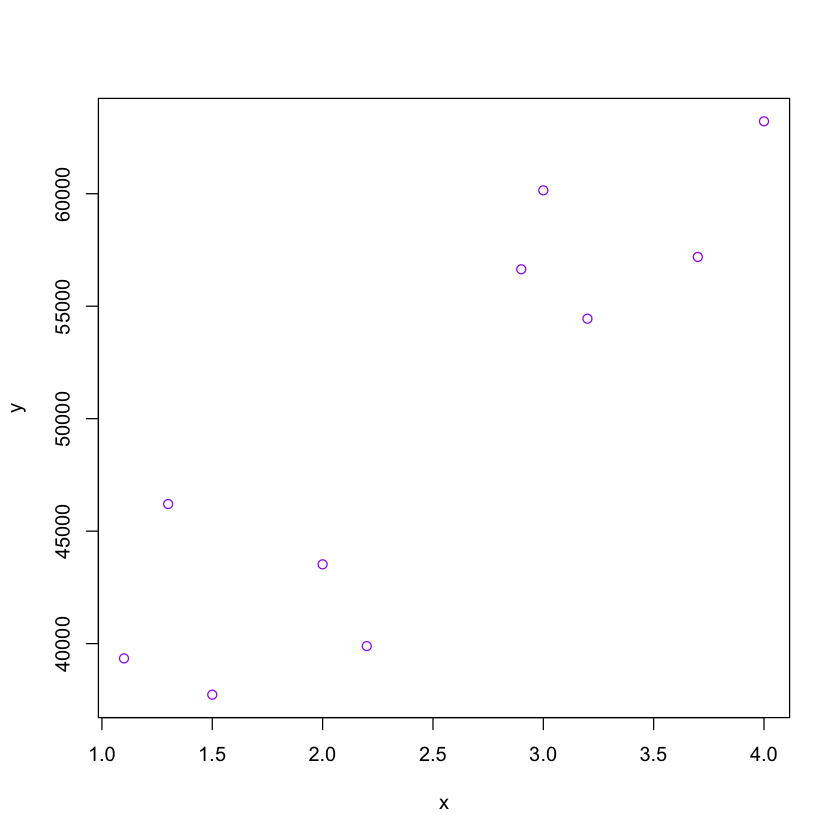

In [9]:
# import csv dataset
df <- read.csv("regression_data.csv")

x <- df$YearsExperience
y <- df$Salary


# make a scatter plot of Salary (y) as a fx of YearsExperience (x)
plot(x, y, col="purple")

## Fit linear regression model 
This code will fit a linear regression model using the R lm() command to the imported data. It will model salary as a fx of years of experience.


In [10]:
model <- lm(Salary ~ YearsExperience, data=df)

slope <- coef(model)[2]
intercept <- coef(model)[1]
r <- cor(x, y)
pred <- predict(model)
mse <- mean((y - pred)^2)
rmse <- sqrt(mse)   

cat("Slope for linear regression:", slope, "\n")
cat("Y-intercept for linear regression:", intercept, "\n")
cat("R value for linear regression:", r, "\n")
cat("MSE for linear regression:", mse, "\n")
cat("RMSE for linear regression:", rmse, "\n")  


Slope for linear regression: 8285.292 
Y-intercept for linear regression: 29203.52 


R value for linear regression: 0.8860878 
MSE for linear regression: 17523844 
RMSE for linear regression: 4186.149 


### Statistical interpretation
- **Slope**: The calculated slope of $8285.29 indicates the expected salary increase for every year of experience
- **Y-intercept**: The calculated y-intercept of $29203.52 indicates the base entry salary (no years of experience)
- **R value**: The R value of 0.89 indicates that there is a strong positive correlation between years of experience and salary, meaning that as years of experience increase, salary should also increase. 
- **MSE**: The MSE value of 17523844 is pretty high, which indicates that the model's predicted values are not super close to the true values. This value can be difficult to interpret because its value is in squared units (ex. squared $ for this dataset), because it measures the average squared difference between the predicted and actual datasets. This statistic is heavily influenced by outliers, and this dataset does contain some outliers, which could account for the high MSE value. The root MSE (RMSE) value is a bit easier to interpret because the units are the same as the original data. The RMSE value is $4186.15, meaning that on average, the model will predict values that are $4186.15 away from the actual data. 

`geom_smooth()` using formula = 'y ~ x'
Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'


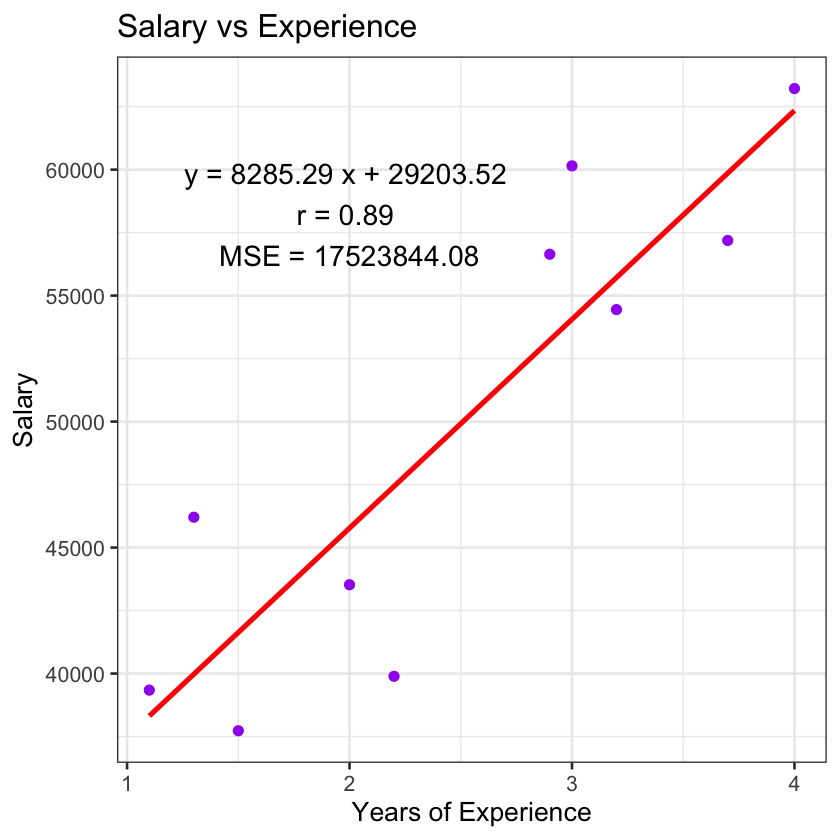

In [18]:
# graph the raw data and the calculated regression line
ggplot(df, aes(x = YearsExperience, y = Salary)) +
    geom_point(color='purple') +
    geom_smooth(method = "lm", se = FALSE, color = 'red') +
    annotate("text", x = 2, y = max(y) - 5000,
             label = paste("y =", round(slope, 2), "x +", round(intercept, 2),
                           "\nr =", round(r, 2), "\nMSE =", round(mse, 2)),
             size = 6) +
    labs(title = "Salary vs Experience", 
         x = "Years of Experience", 
         y = "Salary") +
    theme_bw(base_size = 16)


ggsave("linear_regression_r.png")

In [20]:
# evaluate the model's performance 
summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407
